In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from random import choice, randint
from google.colab import files

plt.style.use('ggplot')

In [2]:
np.random.seed(42)

regions = ['North','South','East','West']
genders = ['Male','Female']
categories = ['Electronics','Fashion','Groceries','Home Decor']

customers = []

for i in range(1,101):

    customer_id = f"C{i:03}"

    customer_name = f"Customer_{i}"

    region = choice(regions)

    gender = choice(genders)

    total_orders = randint(1,20)

    purchase_amount = randint(1000,50000)

    avg_order_value = round(
        purchase_amount/total_orders,2
    )

    recency_days = randint(1,365)

    last_purchase = (
        pd.Timestamp.today() -
        pd.Timedelta(days=recency_days)
    )

    customers.append([
        customer_id,
        customer_name,
        region,
        gender,
        total_orders,
        purchase_amount,
        avg_order_value,
        last_purchase,
        choice(categories)
    ])

df = pd.DataFrame(customers, columns=[
    'Customer_ID',
    'Customer_Name',
    'Region',
    'Gender',
    'Total_Orders',
    'Total_Purchase_Amount',
    'Average_Order_Value',
    'Last_Purchase_Date',
    'Category'
])

df.head()

,Customer_ID,Customer_Name,Region,Gender,Total_Orders,Total_Purchase_Amount,Average_Order_Value,Last_Purchase_Date,Category
0,C001,Customer_1,East,Male,10,31126,3112.60,2025-07-12 13:25:18.386328,Fashion
1,C002,Customer_2,North,Female,14,4362,311.57,2026-05-18 13:25:18.386686,Electronics
2,C003,Customer_3,West,Male,15,11181,745.40,2026-01-11 13:25:18.386735,Groceries
3,C004,Customer_4,North,Male,17,44588,2622.82,2026-03-07 13:25:18.386763,Home Decor
4,C005,Customer_5,East,Male,8,6426,803.25,2025-09-29 13:25:18.386786,Fashion


In [3]:
df.to_csv(
    "Raw_Customer_Dataset.csv",
    index=False
)

files.download(
    "Raw_Customer_Dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
reference_date = pd.Timestamp.today()

df['Recency'] = (
    reference_date -
    df['Last_Purchase_Date']
).dt.days

df['Frequency'] = df['Total_Orders']

df['Monetary'] = df[
    'Total_Purchase_Amount'
]

In [5]:
df['R_Score'] = pd.qcut(
    df['Recency'],
    5,
    labels=[5,4,3,2,1]
)

df['F_Score'] = pd.qcut(
    df['Frequency'].rank(
        method='first'
    ),
    5,
    labels=[1,2,3,4,5]
)

df['M_Score'] = pd.qcut(
    df['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

In [6]:
df['R_Score'] = pd.qcut(
    df['Recency'],
    5,
    labels=[5,4,3,2,1]
)

df['F_Score'] = pd.qcut(
    df['Frequency'].rank(
        method='first'
    ),
    5,
    labels=[1,2,3,4,5]
)

df['M_Score'] = pd.qcut(
    df['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

In [7]:
df['RFM_Score'] = (

    df['R_Score'].astype(int)

    +

    df['F_Score'].astype(int)

    +

    df['M_Score'].astype(int)

)

In [8]:
def segment(score):

    if score >= 13:
        return "Champion"

    elif score >= 10:
        return "Loyal Customer"

    elif score >= 8:
        return "Potential Loyalist"

    elif score >= 6:
        return "At Risk"

    else:
        return "Lost Customer"

df['Customer_Segment'] = (
    df['RFM_Score']
    .apply(segment)
)

In [9]:
df.to_csv(
    "Final_RFM_Dataset.csv",
    index=False
)

files.download(
    "Final_RFM_Dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

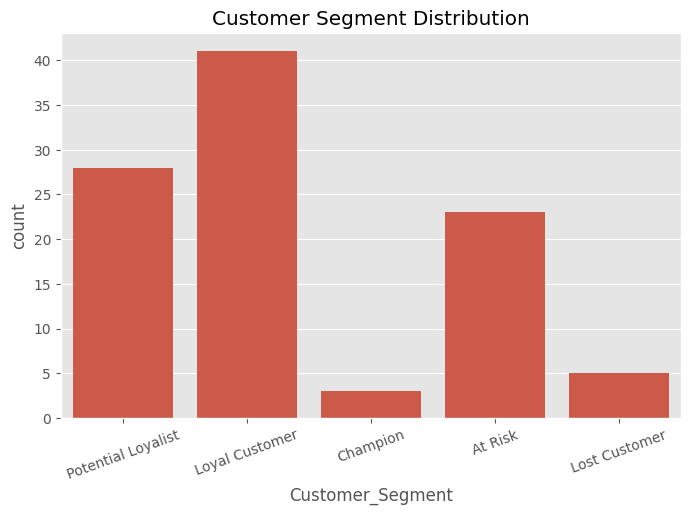

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Customer_Segment'
)

plt.title(
    "Customer Segment Distribution"
)

plt.xticks(rotation=20)

plt.savefig(
    "Chart1_Customer_Segments.png",
    bbox_inches='tight'
)

plt.show()

In [11]:
files.download(
    "Chart1_Customer_Segments.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

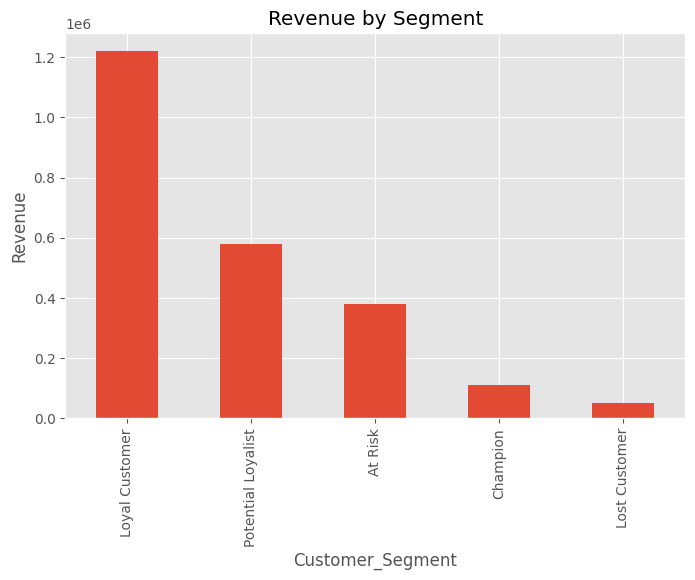

In [12]:
segment_revenue = (

    df.groupby(
        'Customer_Segment'
    )['Monetary']
    .sum()
    .sort_values(
        ascending=False
    )

)

plt.figure(figsize=(8,5))

segment_revenue.plot(
    kind='bar'
)

plt.title(
    "Revenue by Segment"
)

plt.ylabel("Revenue")

plt.savefig(
    "Chart2_Revenue_By_Segment.png",
    bbox_inches='tight'
)

plt.show()

In [13]:
files.download(
    "Chart2_Revenue_By_Segment.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

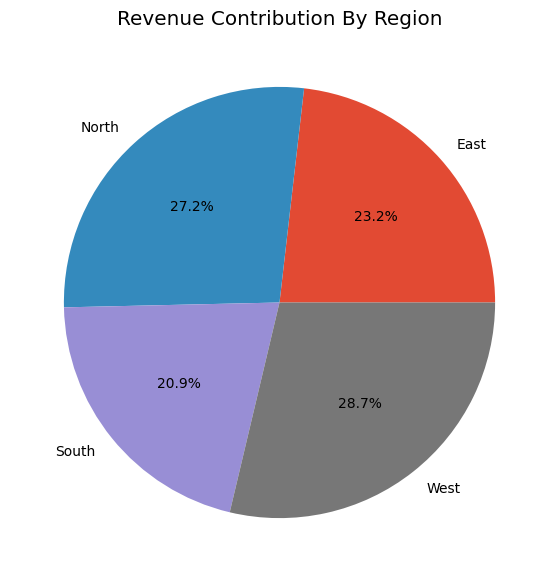

In [14]:
region_sales = (

    df.groupby(
        'Region'
    )['Monetary']
    .sum()

)

plt.figure(figsize=(7,7))

region_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")

plt.title(
    "Revenue Contribution By Region"
)

plt.savefig(
    "Chart3_Region_Revenue.png",
    bbox_inches='tight'
)

plt.show()

In [15]:
files.download(
    "Chart3_Region_Revenue.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

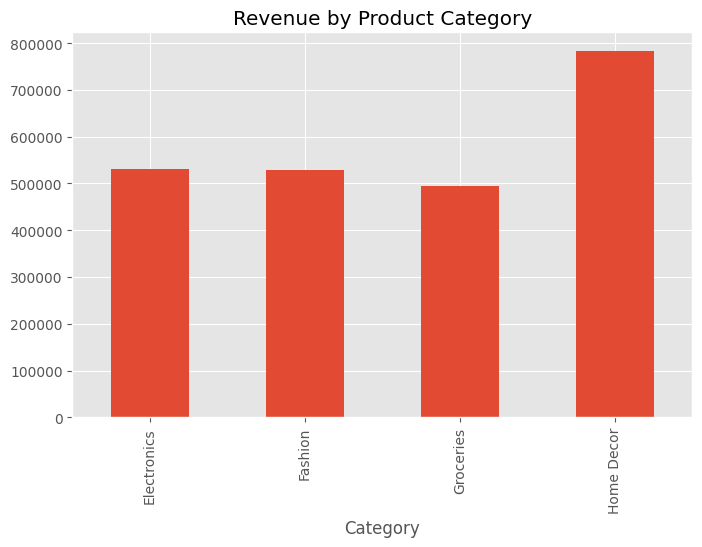

In [16]:
category_sales = (

    df.groupby(
        'Category'
    )['Monetary']
    .sum()

)

plt.figure(figsize=(8,5))

category_sales.plot(
    kind='bar'
)

plt.title(
    "Revenue by Product Category"
)

plt.savefig(
    "Chart4_Category_Analysis.png",
    bbox_inches='tight'
)

plt.show()

In [17]:
files.download(
    "Chart4_Category_Analysis.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_2738/1533228269.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(


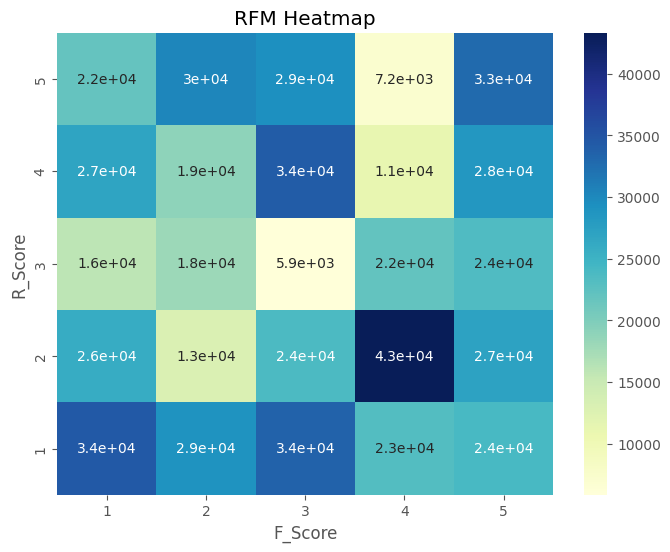

In [19]:
pivot = pd.pivot_table(

    df,

    values='Monetary',

    index='R_Score',

    columns='F_Score',

    aggfunc='mean'

)

plt.figure(figsize=(8,6))

sns.heatmap(

    pivot,

    annot=True,

    cmap='YlGnBu'

)

plt.title(
    "RFM Heatmap"
)

plt.savefig(
    "Chart5_RFM_Heatmap.png",
    bbox_inches='tight'
)

plt.show()

In [20]:
files.download(
    "Chart5_RFM_Heatmap.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

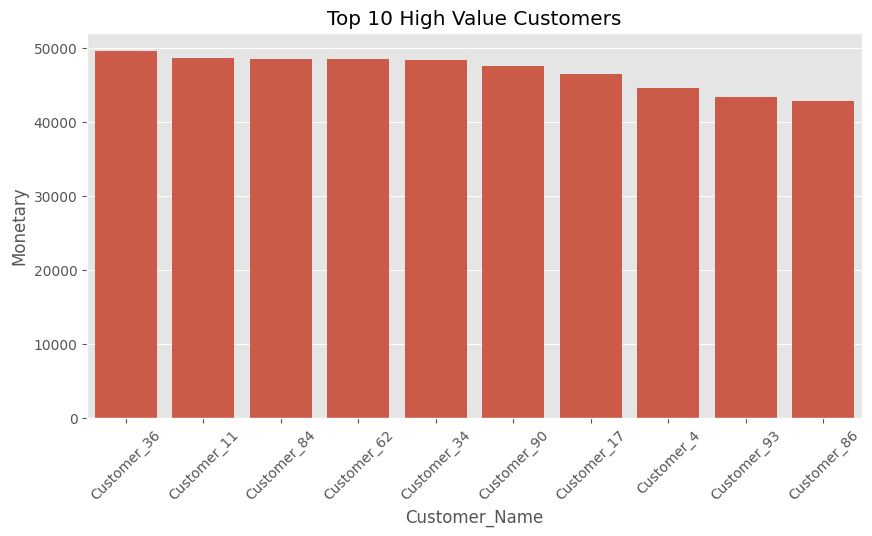

In [21]:
top_customers = (

    df.nlargest(
        10,
        'Monetary'
    )

)

plt.figure(figsize=(10,5))

sns.barplot(

    data=top_customers,

    x='Customer_Name',

    y='Monetary'

)

plt.xticks(rotation=45)

plt.title(
    "Top 10 High Value Customers"
)

plt.savefig(
    "Chart6_High_Value_Customers.png",
    bbox_inches='tight'
)

plt.show()

In [22]:
files.download(
    "Chart6_High_Value_Customers.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
kpi = pd.DataFrame({

'Metric':[

'Total Customers',
'Total Revenue',
'Average Order Value',
'Champion Customers'

],

'Value':[

df.shape[0],

df['Monetary'].sum(),

round(
    df['Average_Order_Value']
    .mean(),2
),

len(
    df[
        df[
            'Customer_Segment'
        ]=='Champion'
    ]
)

]

})

kpi

,Metric,Value
0,Total Customers,100.00
1,Total Revenue,2338390.00
2,Average Order Value,5007.34
3,Champion Customers,3.00


In [24]:
kpi.to_csv(
    "KPI_Report.csv",
    index=False
)

files.download(
    "KPI_Report.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>